## 7.10 QAOA를 이용한 전자구조 계산

In [1]:
# 필요한 임포트
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
from qiskit.primitives import StatevectorSampler  # 호환성 수정: V1 Sampler → V2 StatevectorSampler
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import QAOA
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 비용 해밀토니안 정의: 2큐비트의 Z 항 (계산 기저에서 대각)
hamiltonian = SparsePauliOp.from_list([("ZZ", -1.0), ("ZI", 0.5), ("IZ", 0.5)])

In [3]:
# QAOA 층 수
p = 2

In [4]:
# PauliEvolution 없이 QAOA 앤사츠 구성
def qaoa_ansatz(gamma, beta, num_qubits):
    qc = QuantumCircuit(num_qubits)

    # 하다마드 게이트 초기층 (균등 중첩)
    qc.h(range(num_qubits))

    # p개의 QAOA 층 적용
    for i in range(p):
        # 비용 해밀토니안: ZZ 상호작용
        qc.rzz(2 * gamma[i], 0, 1)

        # 믹서 해밀토니안: 모든 큐비트에 RX
        qc.rx(2 * beta[i], range(num_qubits))

    return qc

In [5]:
# 문제의 큐비트 수
num_qubits = 2

In [6]:
# 최적화기와 샘플러 정의
optimizer = COBYLA(maxiter=100)
sampler = StatevectorSampler()  # 호환성 수정: V2 샘플러

In [7]:
# QAOA 인스턴스 정의
qaoa = QAOA(optimizer=optimizer, reps=p, sampler=sampler)

In [8]:
# 무작위 gamma, beta 값으로 QAOA 앤사츠 생성
gamma = np.random.rand(p)
beta = np.random.rand(p)
qc_qaoa = qaoa_ansatz(gamma, beta, num_qubits)

In [9]:
# 회로에 측정 추가
qc_qaoa.measure_all()

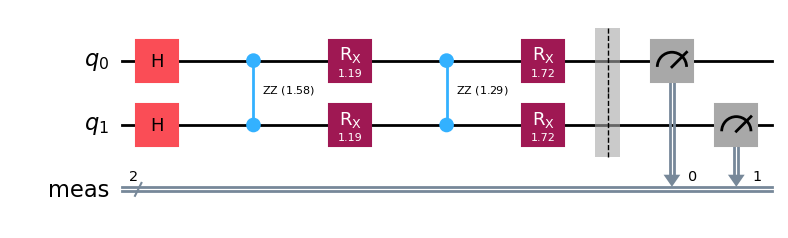

In [10]:
# 회로 그리기
qc_qaoa.draw('mpl')
plt.show()

In [11]:
# AerSimulator로 회로 시뮬레이션
simulator = AerSimulator(method="statevector")

In [12]:
# 상태벡터 시뮬레이터에서 회로 실행
job = simulator.run(qc_qaoa, shots=1024)
result = job.result()
counts = result.get_counts()

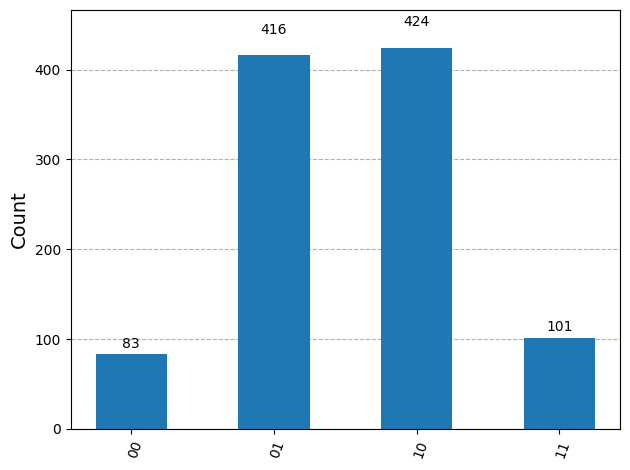

In [13]:
# 최종 측정 히스토그램
plot_histogram(counts)
plt.show()

In [14]:
# 블로흐 구·State City를 위한 상태벡터 시각화
qc_qaoa.remove_final_measurements()  # 시각화를 위해 측정 제거
statevector = Statevector.from_instruction(qc_qaoa)

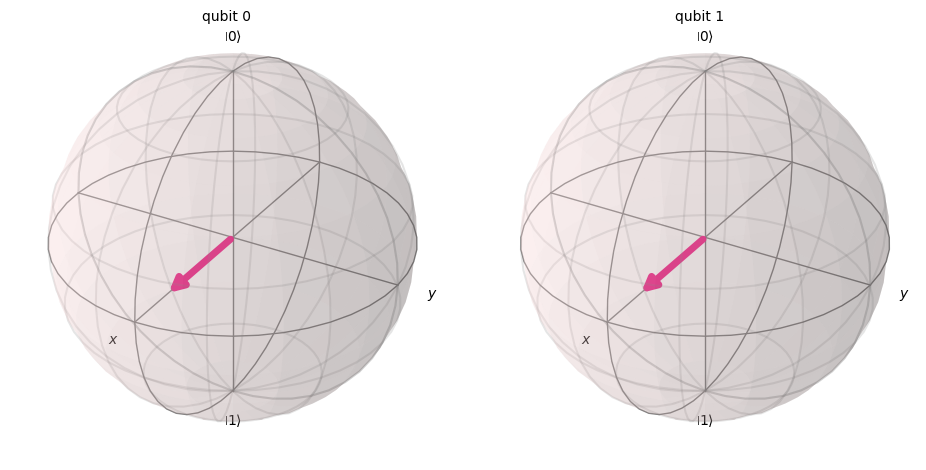

In [15]:
# 모든 큐비트의 블로흐 구 시각화
plot_bloch_multivector(statevector)
plt.show()

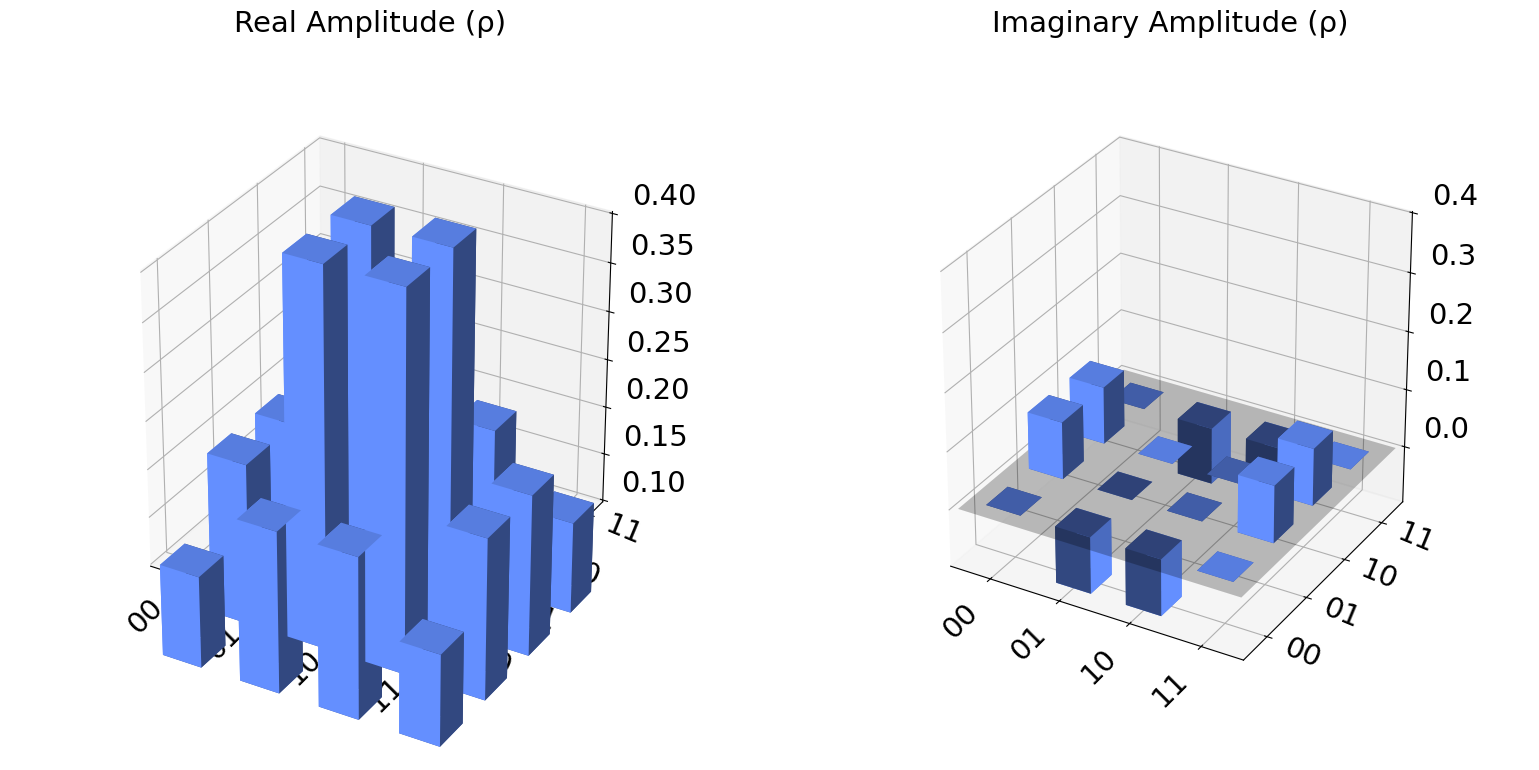

In [16]:
# 전체 양자 상태의 State City 플롯
plot_state_city(statevector)
plt.show()

In [17]:
# 한 큐비트의 축소 밀도행렬을 얻기 위한 부분 대각합
reduced_density_matrix = partial_trace(statevector, [1])

In [18]:
# 축소 밀도행렬 출력
print("축소 밀도행렬 (큐비트 1 추적 제거 후):")
print(reduced_density_matrix)

축소 밀도행렬 (큐비트 1 추적 제거 후):
DensityMatrix([[0.5       -1.43496420e-18j, 0.34521355+5.19802969e-17j],
               [0.34521355-5.33540843e-17j, 0.5       -4.76111449e-18j]],
              dims=(2,))


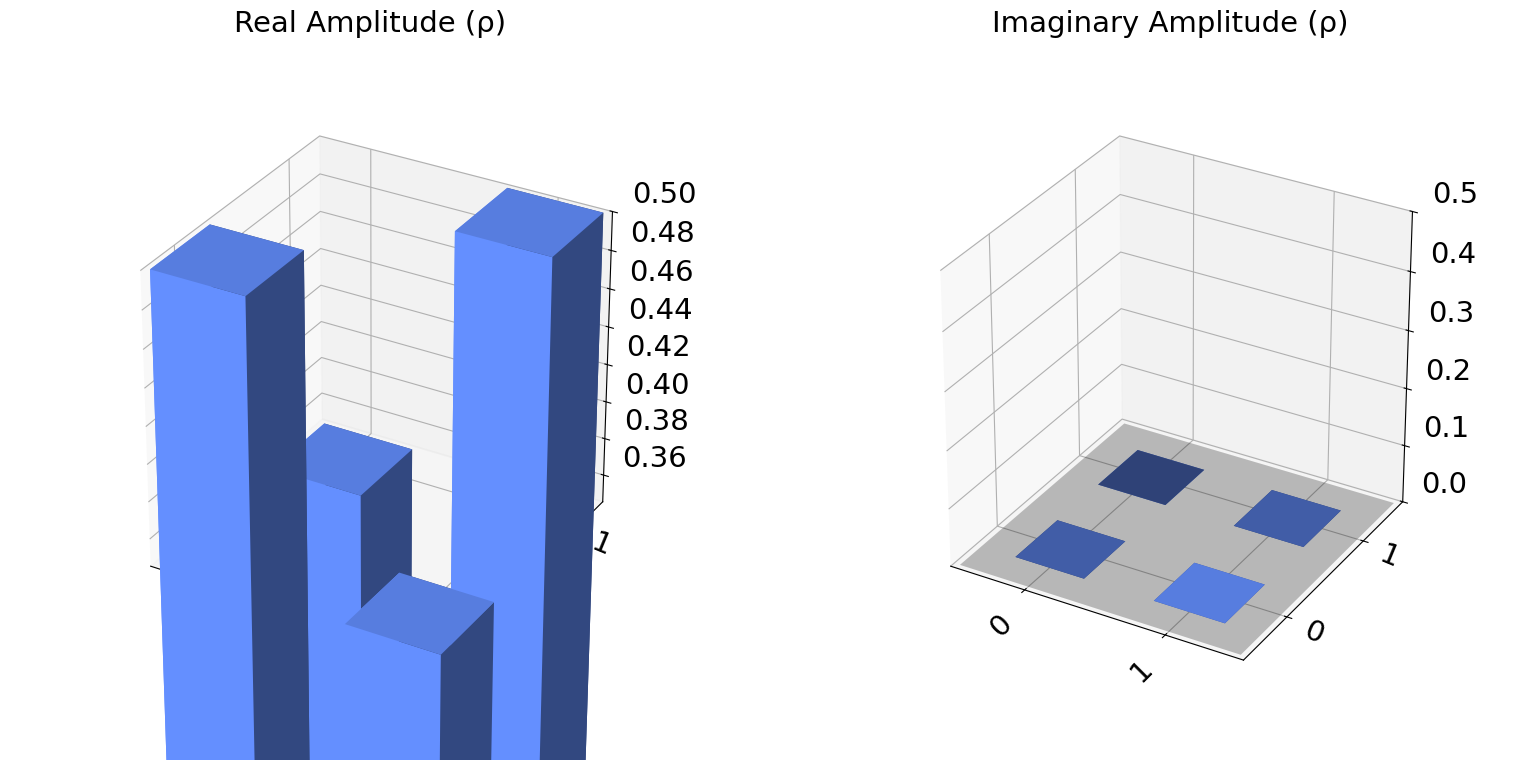

In [19]:
# 부분 양자 상태의 State City 플롯
plot_state_city(reduced_density_matrix)
plt.show()

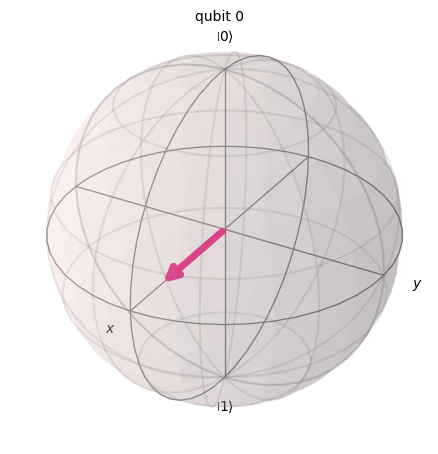

In [20]:
# 축소 큐비트의 블로흐 구
plot_bloch_multivector(reduced_density_matrix)
plt.show()